# SPD-Lasso Training Monitor (Numba)

This notebook imports functions from `DiffusionRWR_model_package.graph_generation.lasso_SPD_numba`, runs training, and plots objective-loss decay so you can inspect convergence behavior with the numba-accelerated implementation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make sure the repository root is importable when running from different working directories.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = None
for candidate in candidates:
    if (candidate / "DiffusionRWR_model_package").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not find project root containing DiffusionRWR_model_package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from DiffusionRWR_model_package.graph_generation.lasso_SPD_numba import run_proximal_on_rna_data, proximal_precision
from DiffusionRWR_model_package.data_sorting import load_data

print(f"Using project root: {project_root}")
print("Using numba module: DiffusionRWR_model_package.graph_generation.lasso_SPD_numba")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']
Using project root: c:\Users\inigo\OneD

In [2]:
# Tune these to inspect different training behaviors.
data_folder = project_root / "DiffusionRWR_model_package" / "data" / "Modelled"
top_n_genes = 600
lam = 0.1
gamma = 0.1
eta = 10
max_iter = 2000

print(f"Data folder: {data_folder}")
print(f"lam={lam}, gamma={gamma}, eta={eta}, max_iter={max_iter}, top_n_genes={top_n_genes}")

Data folder: c:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\DiffusionRWR_model_package\data\Modelled
lam=0.1, gamma=0.1, eta=10, max_iter=2000, top_n_genes=600


In [3]:
# High-level training helper from lasso_SPD_numba.py (returns losses).
Q, losses, metadata = run_proximal_on_rna_data(
    folder_path=data_folder,
    rna_key_contains="rna",
    top_n_genes=20,
    lam=lam,
    gamma=gamma,
    eta=eta,
    max_iter=max_iter,
    make_plot=False,
)

print("Run metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")

print(f"Iterations logged: {len(losses)}")
print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss:   {losses[-1]:.6f}")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']
starting proximal solver...
Run metadat

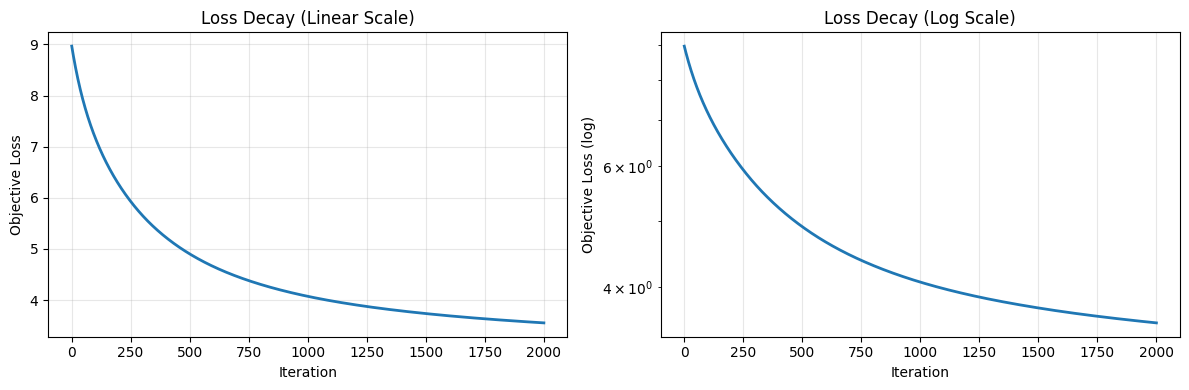

In [4]:
# Plot objective loss decay (linear and log-y views).
iters = np.arange(1, len(losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(iters, losses, linewidth=2)
axes[0].set_title("Loss Decay (Linear Scale)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective Loss")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(iters, losses, linewidth=2)
axes[1].set_title("Loss Decay (Log Scale)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective Loss (log)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Leave-One-Timepoint-Out CV For Lambda

This section tunes `lam` by leaving out one time step at a time, fitting on the remaining time steps, predicting the held-out time step from the fitted precision matrix, and scoring with MSE.

In [5]:
import pandas as pd
lam_values = np.arange(0.001, 1.01, 0.2)

def predict_holdout_from_omega(x_holdout, omega):
    """Predict held-out feature values using x_j = -tau_j * x_-j^T omega_-j,j."""
    x_holdout = np.asarray(x_holdout, dtype=float)
    omega = np.asarray(omega, dtype=float)

    p = omega.shape[0]
    if x_holdout.shape[0] != p:
        raise ValueError(f"Shape mismatch: x_holdout has {x_holdout.shape[0]} features but omega has {p}.")

    tau_hat = 1.0 / np.clip(np.diag(omega), 1e-12, None)
    x_pred = np.empty(p, dtype=float)

    for j in range(p):
        idx = np.arange(p) != j
        x_pred[j] = -tau_hat[j] * (x_holdout[idx] @ omega[idx, j])

    return x_pred


def scale_invariance_r2_from_omega(omega, n_bins=10):
    """Compute scale-invariance R^2 from node connectivity derived from |omega|."""
    abs_omega = np.abs(np.asarray(omega, dtype=float))
    np.fill_diagonal(abs_omega, 0.0)
    connectivity = np.sum(abs_omega, axis=1)
    connectivity = connectivity[np.isfinite(connectivity)]
    connectivity = connectivity[connectivity > 0]

    if connectivity.size < 3:
        return np.nan, np.nan

    k_min = float(np.min(connectivity))
    k_max = float(np.max(connectivity))
    if not np.isfinite(k_min) or not np.isfinite(k_max) or k_max <= k_min:
        return np.nan, np.nan

    bins = np.linspace(k_min, k_max, int(max(3, n_bins)) + 1)
    counts, edges = np.histogram(connectivity, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    probs = counts.astype(float) / max(1.0, float(np.sum(counts)))

    valid = (counts > 0) & (centers > 0) & (probs > 0)
    x = np.log10(centers[valid])
    y = np.log10(probs[valid])

    if x.size < 3:
        return np.nan, np.nan

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))

    if ss_tot <= 0:
        return np.nan, float(slope)

    r2 = 1.0 - ss_res / ss_tot
    return float(r2), float(slope)


def loo_timepoint_cv_for_lambda(
    X_all,
    lam_values,
    gamma=0.1,
    eta=10.0,
    max_iter=400,
    tol=1e-12,
    verbose=True,
    warmup=True,
    warmup_lam=None,
    warmup_iters=5,
    warmup_fold=0,
):
    """
    Leave-one-timepoint-out CV over lambda values using held-out MSE.

    Parameters
    ----------
    X_all : np.ndarray, shape (n_timepoints, n_features)
        Matrix where rows are timepoints and columns are features (genes).
    lam_values : iterable[float]
        Candidate lambda values to evaluate.
    gamma, eta, max_iter : float/int
        Solver hyperparameters used for each fold fit.
    tol : float
        Tiny numerical tolerance when checking if MSE increases across lambdas (diagnostic only).
    verbose : bool
        Print progress.
    warmup : bool
        If True, run one short fit first to trigger numba compilation before timing/comparing.
    warmup_lam : float | None
        Lambda used for warmup fit. Defaults to first lambda in lam_values.
    warmup_iters : int
        Iterations for warmup call.
    warmup_fold : int
        Fold index used for warmup holdout.
    """
    X_all = np.asarray(X_all, dtype=float)
    if X_all.ndim != 2:
        raise ValueError("X_all must be a 2D array: (n_timepoints, n_features).")

    n_time, p = X_all.shape
    if n_time < 2:
        raise ValueError("Need at least 2 timepoints for leave-one-out CV.")

    lam_values = [float(v) for v in lam_values]
    if len(lam_values) == 0:
        raise ValueError("lam_values must contain at least one candidate lambda.")

    if warmup:
        warm_lam = lam_values[0] if warmup_lam is None else float(warmup_lam)
        holdout_idx = int(np.clip(warmup_fold, 0, n_time - 1))
        X_train_warm = np.delete(X_all, holdout_idx, axis=0)
        _ = proximal_precision(
            X_train_warm,
            lam=warm_lam,
            gamma=gamma,
            eta=eta,
            max_iter=max(1, int(warmup_iters)),
            return_omega=True,
            show_ls_loss=False,
        )
        if verbose:
            print(f"Warmup complete (lam={warm_lam}, fold={holdout_idx}).")

    rows = []
    for lam in lam_values:
        fold_mse = []
        if verbose:
            print(f"Evaluating lambda={lam:.6g}")

        for t in range(n_time):
            X_train = np.delete(X_all, t, axis=0)
            x_holdout = X_all[t, :]

            omega_fit, _ = proximal_precision(
                X_train,
                lam=lam,
                gamma=gamma,
                eta=eta,
                max_iter=max_iter,
                return_omega=True,
                show_ls_loss=False,
            )

            x_pred = predict_holdout_from_omega(x_holdout, omega_fit)
            mse_t = float(np.mean((x_pred - x_holdout) ** 2))
            fold_mse.append(mse_t)

        fold_mse = np.asarray(fold_mse, dtype=float)
        rows.append(
            {
                "lam": lam,
                "mean_mse": float(np.mean(fold_mse)),
                "std_mse": float(np.std(fold_mse)),
                "min_mse": float(np.min(fold_mse)),
                "max_mse": float(np.max(fold_mse)),
                "n_folds": int(n_time),
                "fold_mse": fold_mse,
            }
        )

    cv_df = pd.DataFrame(rows).sort_values("mean_mse", ascending=True).reset_index(drop=True)
    best_lam = float(cv_df.loc[0, "lam"])
    mse_diff = np.diff(cv_df["mean_mse"].to_numpy(dtype=float))
    n_local_increases = int(np.sum(mse_diff > tol))

    summary = {
        "n_timepoints": int(n_time),
        "n_features": int(p),
        "best_lambda": best_lam,
        "best_mean_mse": float(cv_df.loc[0, "mean_mse"]),
        "mse_increase_steps_after_sort": n_local_increases,
    }

    return cv_df, summary

In [12]:
# Run the same timepoint LOO-CV over all datasets in the selected folder.
from DiffusionRWR_model_package.graph_generation.tune_params import (
    clustering_coefficient_from_adjacency,
    mean_degree_from_adjacency,
)

top_n_genes = 100  # Set to None to use all genes (may be slow for large datasets).
random_seed = 42  # Change for a different random gene subset.

datasets = load_data(data_folder)
dataset_keys = sorted(datasets.keys())
if not dataset_keys:
    raise ValueError("No datasets found in the selected data folder")

lam_grid = np.arange(0.021, 0.51, 0.01)
cv_max_iter = 2000
gamma = 0.02
eta = 20.0
metric_max_iter = 400  # Increase toward cv_max_iter for stricter convergence if needed.

cv_results_by_dataset = {}
cv_summary_rows = []

for ds_i, ds_key in enumerate(dataset_keys):
    print(f"\n=== Dataset: {ds_key} ===")
    ds_df = datasets[ds_key].dropna(axis=0, how="any")

    if top_n_genes is not None and top_n_genes > 0 and len(ds_df) > top_n_genes:
        rng = np.random.default_rng(random_seed + ds_i)
        sampled_idx = rng.choice(ds_df.index.to_numpy(), size=int(top_n_genes), replace=False)
        ds_df = ds_df.loc[sampled_idx]

    X_ds = ds_df.T.to_numpy(dtype=float)
    print(f"CV matrix shape (timepoints x features): {X_ds.shape}")

    cv_results_ds, cv_summary_ds = loo_timepoint_cv_for_lambda(
        X_all=X_ds,
        lam_values=lam_grid,
        gamma=gamma,
        eta=eta,
        max_iter=cv_max_iter,
        verbose=True,
        warmup=True,
        warmup_iters=5,
        warmup_fold=0,
        warmup_lam=float(lam_grid[0]),
    )

    # Add graph metrics per lambda for this dataset.
    cv_plot_ds = cv_results_ds.sort_values("lam").reset_index(drop=True)
    mean_degree_values = []
    clustering_coeff_values = []
    scale_inv_r2_values = []
    scale_inv_slope_values = []
    for lam_i in cv_plot_ds["lam"].to_numpy(dtype=float):
        omega_full, _ = proximal_precision(
            X_ds,
            lam=float(lam_i),
            gamma=gamma,
            eta=eta,
            max_iter=metric_max_iter,
            return_omega=True,
            show_ls_loss=False,
        )

        mean_degree_values.append(mean_degree_from_adjacency(np.abs(omega_full)))
        clustering_coeff_values.append(clustering_coefficient_from_adjacency(omega_full))
        r2_i, slope_i = scale_invariance_r2_from_omega(omega_full, n_bins=10)
        scale_inv_r2_values.append(r2_i)
        scale_inv_slope_values.append(slope_i)

    cv_plot_ds["mean_degree"] = np.asarray(mean_degree_values, dtype=float)
    cv_plot_ds["clustering_coefficient"] = np.asarray(clustering_coeff_values, dtype=float)
    cv_plot_ds["scale_inv_r2"] = np.asarray(scale_inv_r2_values, dtype=float)
    cv_plot_ds["scale_inv_slope"] = np.asarray(scale_inv_slope_values, dtype=float)

    best_lam_ds = float(cv_summary_ds["best_lambda"])

    cv_summary_rows.append(
        {
            "dataset": ds_key,
            "n_timepoints": int(cv_summary_ds["n_timepoints"]),
            "n_features": int(cv_summary_ds["n_features"]),
            "best_lambda": best_lam_ds,
            "best_mean_mse": float(cv_summary_ds["best_mean_mse"]),
        }
    )

    cv_results_by_dataset[ds_key] = {
        "X": X_ds,
        "cv_results": cv_results_ds,
        "cv_summary": cv_summary_ds,
        "cv_plot": cv_plot_ds,
    }

# Combined summary over all datasets.
cv_summary_all = pd.DataFrame(cv_summary_rows).sort_values("best_mean_mse", ascending=True).reset_index(drop=True)
display(cv_summary_all)

# Choose one dataset to visualize in detail (best by CV MSE).
plot_dataset = cv_summary_all.loc[0, "dataset"]
plot_pack = cv_results_by_dataset[plot_dataset]
cv_plot = plot_pack["cv_plot"]
cv_results = plot_pack["cv_results"]
cv_summary = plot_pack["cv_summary"]
X_all = plot_pack["X"]

print(f"\nDetailed plots for dataset: {plot_dataset}")
display(cv_results[["lam", "mean_mse", "std_mse", "min_mse", "max_mse", "n_folds"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Panel 1: CV error + mean degree
ax1 = axes[0]
ax1.plot(cv_plot["lam"], cv_plot["mean_mse"], marker="o", linewidth=2, color="tab:blue", label="Mean LOO MSE")
ax1.set_xlabel("lambda")
ax1.set_ylabel("Mean LOO MSE", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(cv_plot["lam"], cv_plot["mean_degree"], marker="s", linewidth=2, color="tab:red", label="Mean degree")
ax1b.set_ylabel("Mean degree", color="tab:red")
ax1b.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines1b, labels1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labels1 + labels1b, loc="best")
ax1.set_title("MSE and Mean Degree")

# Panel 2: clustering coefficient vs lambda
ax2 = axes[1]
ax2.plot(cv_plot["lam"], cv_plot["clustering_coefficient"], marker="^", linewidth=2, color="tab:green")
ax2.set_xlabel("lambda")
ax2.set_ylabel("Clustering coefficient")
ax2.set_title("Clustering Coefficient vs Lambda")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(cv_plot[["lam", "mean_mse", "mean_degree", "clustering_coefficient", "scale_inv_r2", "scale_inv_slope"]])

best_lam_cv = float(cv_summary["best_lambda"])

print(f"\nBest lambda from LOO-CV ({plot_dataset}): {best_lam_cv:.6g}")
print(f"Iterations used for graph-metric fits: {metric_max_iter}")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']

=== Dataset: overlap_filtered_k20me3_m

,dataset,n_timepoints,n_features,best_lambda,best_mean_mse
0,overlap_filtered_k27me3_m_v2,5,100,0.141,0.020328
1,overlap_filtered_k20me3_m_v2,5,100,0.121,0.025643
2,overlap_filtered_k9me2_m_v2,5,100,0.341,0.032008
3,overlap_filtered_rna_ai_m_v2,5,100,0.171,0.034111



Detailed plots for dataset: overlap_filtered_k27me3_m_v2


,lam,mean_mse,std_mse,min_mse,max_mse,n_folds
0,0.141,0.020328,0.008739,0.010319,0.033888,5
1,0.131,0.020371,0.008756,0.010660,0.035046,5
2,0.151,0.020493,0.008951,0.010146,0.032715,5
3,0.161,0.020716,0.009305,0.010152,0.032000,5
4,0.171,0.020828,0.009475,0.010269,0.032852,5
5,0.121,0.020907,0.009163,0.011531,0.037137,5
6,0.181,0.021193,0.009878,0.010512,0.035063,5
7,0.191,0.021812,0.010537,0.010835,0.038065,5
8,0.111,0.022449,0.009960,0.013422,0.040559,5
9,0.201,0.022589,0.011394,0.011147,0.041313,5


C:\Users\inigo\AppData\Local\Temp\ipykernel_31344\4058245399.py:140: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,lam,mean_mse,mean_degree,clustering_coefficient,scale_inv_r2,scale_inv_slope
0,0.021,0.108109,1628.582573,0.036850,0.244167,-0.856659
1,0.031,0.099534,739.562227,0.033429,0.484770,-1.524372
2,0.041,0.093315,418.178915,0.031582,0.527649,-1.845323
3,0.051,0.078897,266.144782,0.033016,0.492775,-1.699877
4,0.061,0.062507,185.976314,0.030172,0.428508,-1.576436
5,0.071,0.049026,138.276657,0.028221,0.426350,-1.680621
6,0.081,0.038390,107.649900,0.025990,0.506965,-2.054071
7,0.091,0.030447,86.863443,0.023523,0.393271,-1.667428
8,0.101,0.025341,72.142521,0.022224,0.240862,-1.335110
9,0.111,0.022449,61.232895,0.021084,0.203722,-1.373978



Best lambda from LOO-CV (overlap_filtered_k27me3_m_v2): 0.141
Iterations used for graph-metric fits: 400


In [14]:
# Plot mean MSE, scale invariance, and mean absolute degree curves for all datasets.
if "cv_results_by_dataset" not in globals() or not cv_results_by_dataset:
    raise RuntimeError("Run the previous CV cell first so cv_results_by_dataset is available.")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ds_key, pack in cv_results_by_dataset.items():
    df_i = pack["cv_plot"].sort_values("lam")
    lam_vals = df_i["lam"].to_numpy(dtype=float)

    axes[0].plot(
        lam_vals,
        df_i["mean_mse"].to_numpy(dtype=float),
        marker="o",
        linewidth=1.8,
        alpha=0.9,
        label=ds_key,
    )

    axes[1].plot(
        lam_vals,
        df_i["scale_inv_r2"].to_numpy(dtype=float),
        marker="^",
        linewidth=1.8,
        alpha=0.9,
        label=ds_key,
    )

    axes[2].plot(
        lam_vals,
        df_i["mean_degree"].to_numpy(dtype=float),
        marker="s",
        linewidth=1.8,
        alpha=0.9,
        label=ds_key,
    )

axes[0].set_xlabel("lambda")
axes[0].set_ylabel("Mean LOO MSE")
axes[0].set_title("Mean LOO MSE vs Lambda")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("lambda")
axes[1].set_ylabel("Scale invariance R^2")
axes[1].set_title("Scale Invariance vs Lambda")
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel("lambda")
axes[2].set_ylabel("Mean absolute degree")
axes[2].set_title("Mean Absolute Degree vs Lambda")
axes[2].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=8)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

C:\Users\inigo\AppData\Local\Temp\ipykernel_31344\386567673.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [15]:
# Fix plotting backend after importing tune_params (which sets Agg).
import matplotlib.pyplot as plt
plt.switch_backend("module://matplotlib_inline.backend_inline")
print(f"Active matplotlib backend: {plt.get_backend()}")

Active matplotlib backend: module://matplotlib_inline.backend_inline


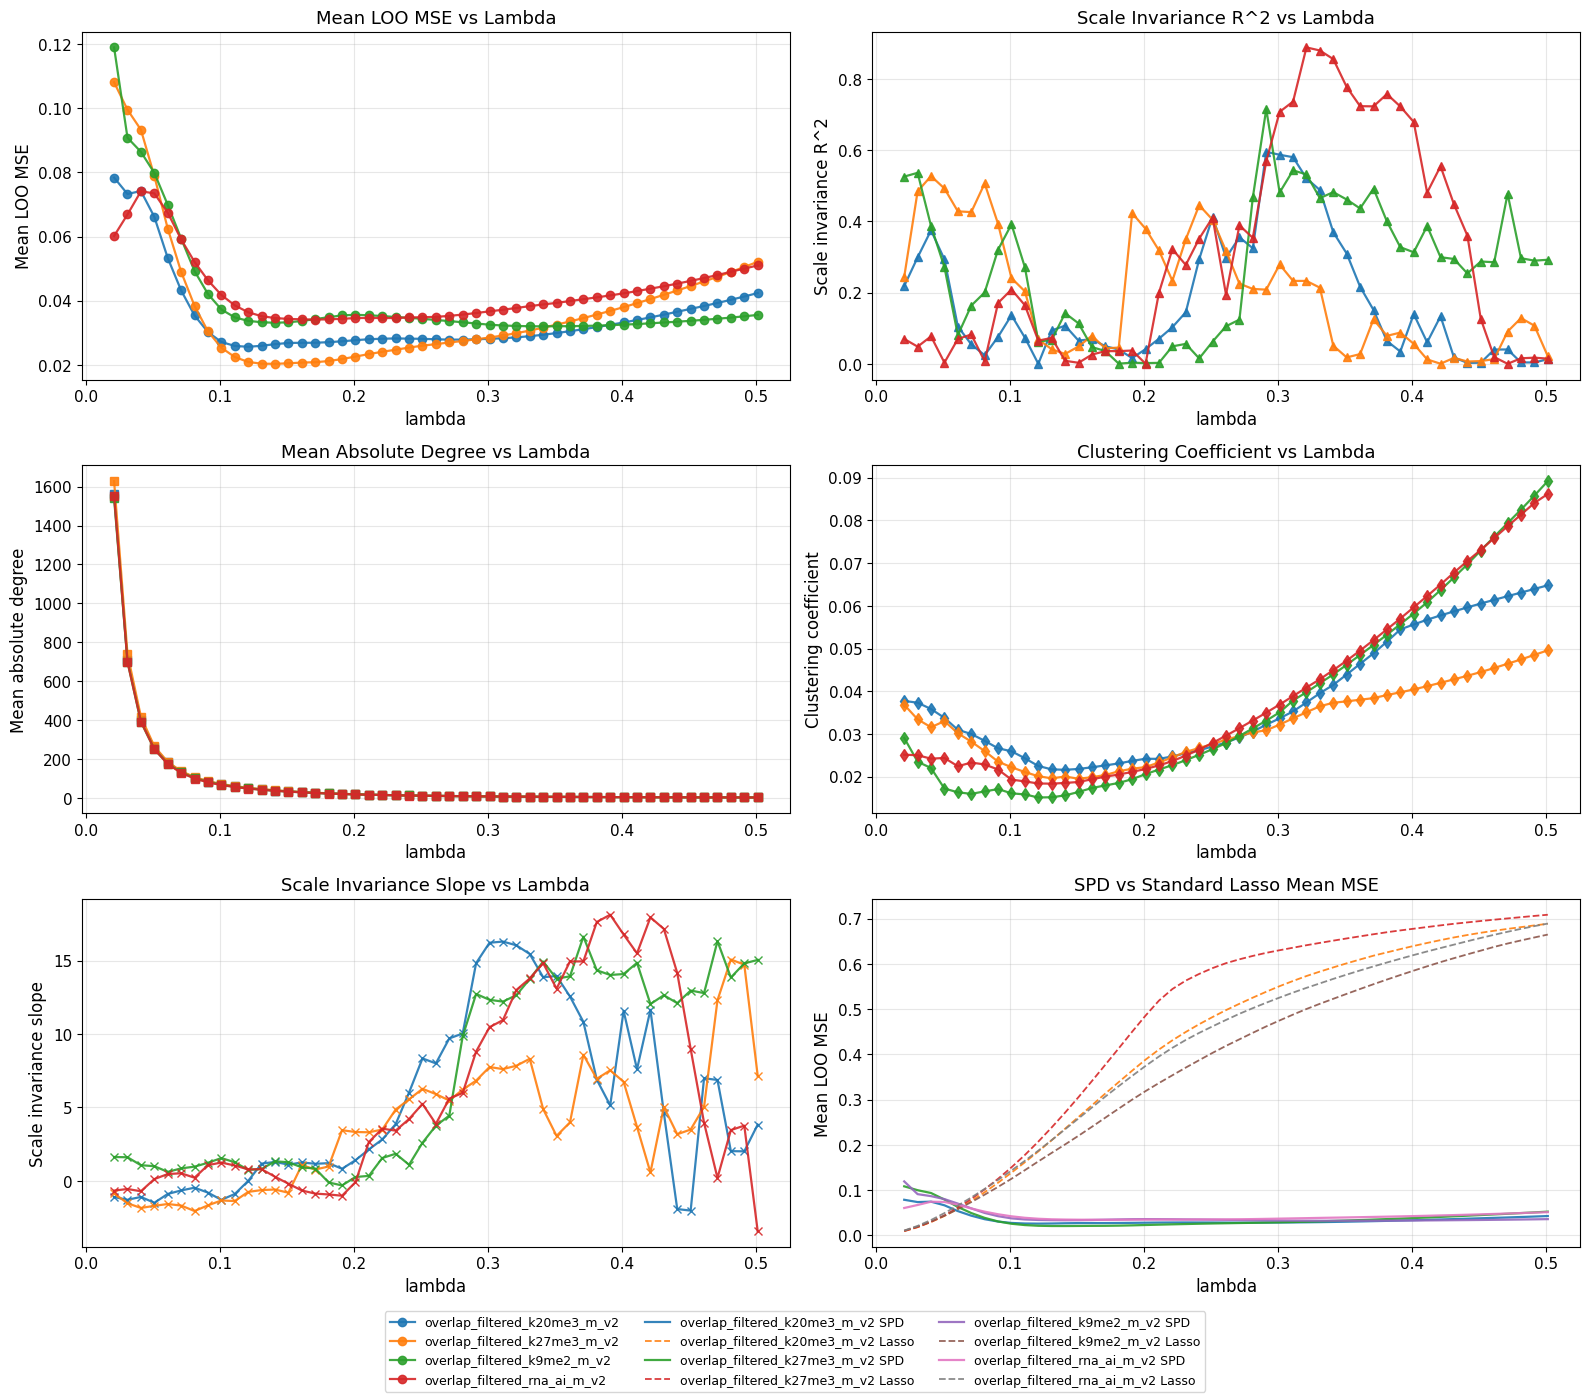

In [20]:
# Plot everything: all available metrics across all datasets.
if "cv_results_by_dataset" not in globals() or not cv_results_by_dataset:
    raise RuntimeError("Run Cell 8 first so cv_results_by_dataset is available.")

title_fs = 13
label_fs = 12
tick_fs = 11
legend_fs = 9

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()

for ds_key, pack in cv_results_by_dataset.items():
    df_i = pack["cv_plot"].sort_values("lam")
    lam_vals = df_i["lam"].to_numpy(dtype=float)

    axes[0].plot(lam_vals, df_i["mean_mse"].to_numpy(dtype=float), marker="o", linewidth=1.6, alpha=0.9, label=ds_key)
    axes[1].plot(lam_vals, df_i["scale_inv_r2"].to_numpy(dtype=float), marker="^", linewidth=1.6, alpha=0.9, label=ds_key)
    axes[2].plot(lam_vals, df_i["mean_degree"].to_numpy(dtype=float), marker="s", linewidth=1.6, alpha=0.9, label=ds_key)
    axes[3].plot(lam_vals, df_i["clustering_coefficient"].to_numpy(dtype=float), marker="d", linewidth=1.6, alpha=0.9, label=ds_key)
    axes[4].plot(lam_vals, df_i["scale_inv_slope"].to_numpy(dtype=float), marker="x", linewidth=1.6, alpha=0.9, label=ds_key)

# Optional SPD vs Standard Lasso CV-MSE panel if comparison objects exist.
if "lasso_cv_by_dataset" in globals() and lasso_cv_by_dataset:
    for ds_key in sorted(cv_results_by_dataset.keys()):
        spd_df = cv_results_by_dataset[ds_key]["cv_results"].sort_values("lam")
        lasso_df = lasso_cv_by_dataset[ds_key].sort_values("lam")
        axes[5].plot(spd_df["lam"], spd_df["mean_mse"], linewidth=1.6, alpha=0.9, label=f"{ds_key} SPD")
        axes[5].plot(lasso_df["lam"], lasso_df["mean_mse"], linestyle="--", linewidth=1.3, alpha=0.9, label=f"{ds_key} Lasso")
    axes[5].set_title("SPD vs Standard Lasso Mean MSE", fontsize=title_fs)
else:
    axes[5].axis("off")
    axes[5].text(0.5, 0.5, "Run the Lasso comparison cell to populate this panel.", ha="center", va="center", fontsize=label_fs)

axes[0].set_title("Mean LOO MSE vs Lambda", fontsize=title_fs)
axes[1].set_title("Scale Invariance R^2 vs Lambda", fontsize=title_fs)
axes[2].set_title("Mean Absolute Degree vs Lambda", fontsize=title_fs)
axes[3].set_title("Clustering Coefficient vs Lambda", fontsize=title_fs)
axes[4].set_title("Scale Invariance Slope vs Lambda", fontsize=title_fs)

for i in range(5):
    axes[i].set_xlabel("lambda", fontsize=label_fs)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis="both", labelsize=tick_fs)
axes[0].set_ylabel("Mean LOO MSE", fontsize=label_fs)
axes[1].set_ylabel("Scale invariance R^2", fontsize=label_fs)
axes[2].set_ylabel("Mean absolute degree", fontsize=label_fs)
axes[3].set_ylabel("Clustering coefficient", fontsize=label_fs)
axes[4].set_ylabel("Scale invariance slope", fontsize=label_fs)
axes[5].set_xlabel("lambda", fontsize=label_fs)
axes[5].set_ylabel("Mean LOO MSE", fontsize=label_fs)
axes[5].grid(True, alpha=0.3)
axes[5].tick_params(axis="both", labelsize=tick_fs)

handles, labels = axes[0].get_legend_handles_labels()
if "lasso_cv_by_dataset" in globals() and lasso_cv_by_dataset:
    h2, l2 = axes[5].get_legend_handles_labels()
    handles = handles + h2
    labels = labels + l2

fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=legend_fs)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()